# Analyse du sondage pôle N MineSabords

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme()

In [97]:
df = pd.read_csv("data/poll.csv")
df.head()

,Horodateur,Tu es en...,Les raisons pour lesquelles tu prends part à un évènement entreprise...,"Les domaines d'activités qui t'intéressent le plus (1 = domaine préféré, 9 = moins intéressante) [1]","Les domaines d'activités qui t'intéressent le plus (1 = domaine préféré, 9 = moins intéressante) [2]","Les domaines d'activités qui t'intéressent le plus (1 = domaine préféré, 9 = moins intéressante) [3]","Les domaines d'activités qui t'intéressent le plus (1 = domaine préféré, 9 = moins intéressante) [4]","Les domaines d'activités qui t'intéressent le plus (1 = domaine préféré, 9 = moins intéressante) [5]","Les domaines d'activités qui t'intéressent le plus (1 = domaine préféré, 9 = moins intéressante) [6]","Les domaines d'activités qui t'intéressent le plus (1 = domaine préféré, 9 = moins intéressante) [7]",...,Un domaine n'apparaissant pas dans la question précédente ?,"Y a-t-il un type de fonction qui t'intéresse particulièrement dans une entreprise ?\n( par ex : R&D, recherche fondamentale, conseil, services et apps, etc... )",Les types d'évènements que tu préfères...,Qu'espères-tu obtenir d'un évènement entreprise,Qu'elles sont les principales choses que tu veux savoir sur une entreprise ?,Une entreprise particulière que tu aimerais rencontrer ?,"Es-tu intéressé.e par la création d'un forum ""entreprises publiques"" ?","Es-tu intéressé.e par la mise en place d'un forum sur le secteur ""énergie et environnement"" ?",Es-tu intéressé.e par la mise en place d'un forum Start-up,Une dernière chose ? :)
0,2026/03/13 8:26:22 PM UTC+2,1A IC,la renommée de l'entreprise;le domaine d'activ...,Énergie et Environnement;Aéronautique;Économie...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,les amphis entreprises;les études de cas,NaN,NaN,NaN,Why not,oui,oui,NaN
1,2026/03/16 6:00:17 PM UTC+2,1A IC,le domaine d'activité de l'entreprise,Environnement,Énergie,Robotique et Automatisation,Économie et Finance,Transports,"Numérique, Informatique et IA",Santé et Biotechnologies,...,NaN,Recherche ou R&D,les amphis entreprises;les tables rondes;les v...,"Rencontrer des travailleurs, découvrir des ent...",Variété d'emplois,"Des services publics, CNRS, EDF, SNCF...",oui,oui,non,NaN
2,2026/03/16 6:21:59 PM UTC+2,1A IC,la présence d'un repas lors de l'évènement,Aéronautique,Mode et Luxe,Santé et Biotechnologies,"Numérique, Informatique et IA",Transports,Robotique et Automatisation,Environnement,...,Automobile,R&D,les amphis entreprises;les tables rondes,NaN,NaN,NaN,oui,oui,oui,NaN
3,2026/03/16 7:36:49 PM UTC+2,1A IC,la recherche d'un stage,Énergie,Environnement,Robotique et Automatisation,"Numérique, Informatique et IA",Aéronautique,Mode et Luxe,Économie et Finance,...,NaN,NaN,les études de cas,NaN,NaN,NaN,non,Non,oui,NaN
4,2026/03/17 10:58:03 AM UTC+2,1A IC,le domaine d'activité de l'entreprise,Aéronautique,Énergie,Santé et Biotechnologies,"Numérique, Informatique et IA",Robotique et Automatisation,Transports,Environnement,...,NaN,r et d,les tables rondes,NaN,NaN,NaN,oui,oui,oui,NaN


In [98]:
print("Nombre de réponses :", len(df))

Nombre de réponses : 112


### Répartition des votant.e.s par année d'étude

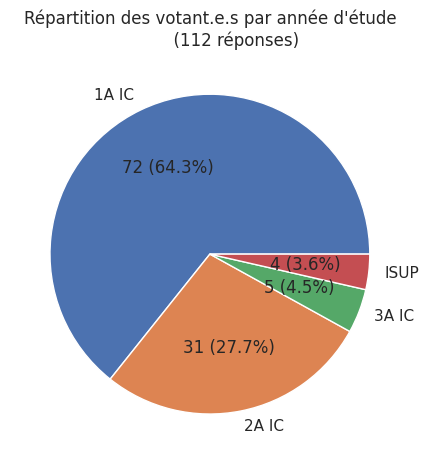

In [99]:
prom = df["Tu es en..."].value_counts()
total = prom.sum()

plt.pie(prom, labels=prom.index,
        autopct=lambda pct: f"{int(round(pct * total / 100.0))} ({pct:.1f}%)")

plt.title(f"""Répartition des votant.e.s par année d'étude
          ({len(df)} réponses)""")

plt.tight_layout()
plt.savefig("plots/prom.svg", bbox_inches="tight")
plt.savefig("plots/prom.pdf", bbox_inches="tight")
plt.show()

### Les raisons poussant à aller à un événement

In [100]:
reasons_data = df["Les raisons pour lesquelles tu prends part à un évènement entreprise..."].value_counts()

# each reason is separated by a semicolon
# so we need to split them and count them
reasons = {}
type_of_meal = {}

not_interested = ["J'y vais pas...",
                  "Je n'y ai jamais pris part",
                  "En vrai j’y participe pas"]

cocktail_lunch = ["La présence d'un repas lors de l'évènement",
                  "La présence d'un cocktail lors de l'évènement"]

combined_label = "Présence d'un repas ou cocktail lors de l'évènement"
cocktail_count = 0
meal_count = 0

for reason_list in reasons_data.index:
    count = reasons_data[reason_list]

    meal_already_counted = False

    for reason in reason_list.split(";"):
        reason = reason.strip().lower().capitalize()

        if reason in not_interested:
            reason = "Jamais pris part à un événement"

        if reason in cocktail_lunch :
            if reason == "La présence d'un cocktail lors de l'évènement":
                cocktail_count += count
                
            else:
                meal_count += count

            if not meal_already_counted :
                reason = combined_label
                meal_already_counted = True

            else:
                continue

        if reason not in reasons:
            reasons[reason] = 0

        reasons[reason] += count

print(reasons)
print(f"{combined_label} -> cocktail: {cocktail_count}, repas: {meal_count}")

{"La renommée de l'entreprise": 54, "Le domaine d'activité de l'entreprise": 93, "La recherche d'un stage": 48, "Présence d'un repas ou cocktail lors de l'évènement": 75, "La politique éthique de l'entreprise": 45, "Le fait de ne pas connaître l'entreprise présentée": 30, 'Jamais pris part à un événement': 3, "Donner de l'argent au bde": 1}
Présence d'un repas ou cocktail lors de l'évènement -> cocktail: 38, repas: 75


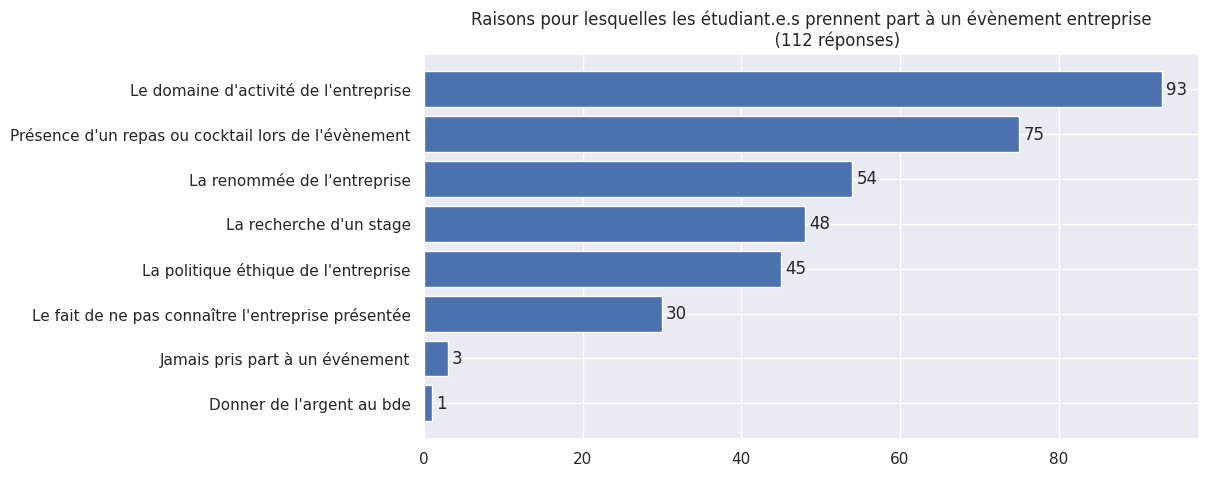

In [ ]:
reasons = dict(sorted(reasons.items(), key=lambda item: item[1]))

labels = list(reasons.keys())

plt.figure(figsize=(10, 5))

bars = plt.barh(labels, list(reasons.values()))
plt.bar_label(bars, padding=3)

plt.title(f"""Raisons pour lesquelles les étudiant.e.s prennent part à un évènement entreprise
          ({len(df)} réponses)""")

plt.savefig("plots/reasons.svg", bbox_inches="tight")
plt.savefig("plots/reasons.pdf", bbox_inches="tight")
plt.show()

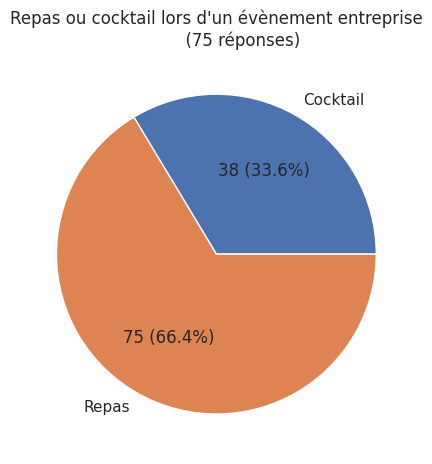

In [102]:
total = cocktail_count + meal_count
amount_voters = reasons[combined_label]

plt.pie([cocktail_count, meal_count], labels=["Cocktail", "Repas"],
        autopct=lambda pct: f"{int(round(pct * total / 100.0))} ({pct:.1f}%)")

plt.title(f"""Repas ou cocktail lors d'un évènement entreprise
          ({amount_voters} réponses)""")

plt.tight_layout()
plt.savefig("plots/meal_cocktail.svg", bbox_inches="tight")
plt.savefig("plots/meal_cocktail.pdf", bbox_inches="tight")
plt.show()

## Les domaines attirant le plus

Sur cette question, on demandait aux votant.e.s de noter les différents domaines proposés en fonction de leur intérêt.

In [103]:
question_prefix = "Les domaines d'activités qui t'intéressent le plus"
question_cols = [col for col in df.columns if col.startswith(question_prefix)]

ranked_domains = df[question_cols].copy()
max_rank = len(question_cols)

records = []
rows = ranked_domains.values.tolist()

for row in rows:
    for col_idx in range(max_rank):
        value = row[col_idx]
        if pd.isna(value):
            continue

        parts = [part.strip() for part in str(value).split(";") if part.strip()]
        if not parts:
            continue

        expanded_parts = []
        for part in parts:
            # Patch due to an old version of the survey
            # (Only 2 cases in the dataset, so we can do it manually)
            if part == "Énergie et Environnement":
                expanded_parts.extend(["Énergie", "Environnement"])
            else:
                expanded_parts.append(part)

        # Rank 1..9 according to columns [1]..[9].
        current_rank = col_idx + 1

        # If several domains are stored in one cell, distribute them
        # across following ranks to avoid a merged category.
        for domain in expanded_parts:
            if current_rank > max_rank:
                break

            records.append({
                "rank": current_rank,
                "domain": domain,
                "points": 10 - current_rank,
            })
            current_rank += 1

stats = {}
for record in records:
    domain = record["domain"]
    rank = record["rank"]
    points = record["points"]

    if domain not in stats:
        stats[domain] = {
            "total_score": 0,
            "rank_sum": 0,
            "mention_count": 0,
            "top1_count": 0,
        }

    stats[domain]["total_score"] += points
    stats[domain]["rank_sum"] += rank
    stats[domain]["mention_count"] += 1
    if rank == 1:
        stats[domain]["top1_count"] += 1

domain_rows = []
for domain, values in stats.items():
    domain_rows.append({
        "domain": domain,
        "total_score": values["total_score"],
        "average_rank": values["rank_sum"] / values["mention_count"],
        "mention_count": values["mention_count"],
        "top1_count": values["top1_count"],
    })

domain_stats = pd.DataFrame(domain_rows).set_index("domain")
domain_stats = domain_stats.sort_values(["total_score", "top1_count", "mention_count"], ascending=False)

n_domain_responses = int(ranked_domains.notna().any(axis=1).sum())
domain_stats.head(10)

,total_score,average_rank,mention_count,top1_count
domain,,,,
Énergie,807,3.330579,121,30
Environnement,675,3.918919,111,22
Transports,587,4.614679,109,8
Aéronautique,566,4.991150,113,13
Robotique et Automatisation,560,4.954955,111,6
"Numérique, Informatique et IA",557,4.842593,108,14
Santé et Biotechnologies,534,5.145455,110,8
Économie et Finance,471,5.718182,110,8
Mode et Luxe,268,7.563636,110,3


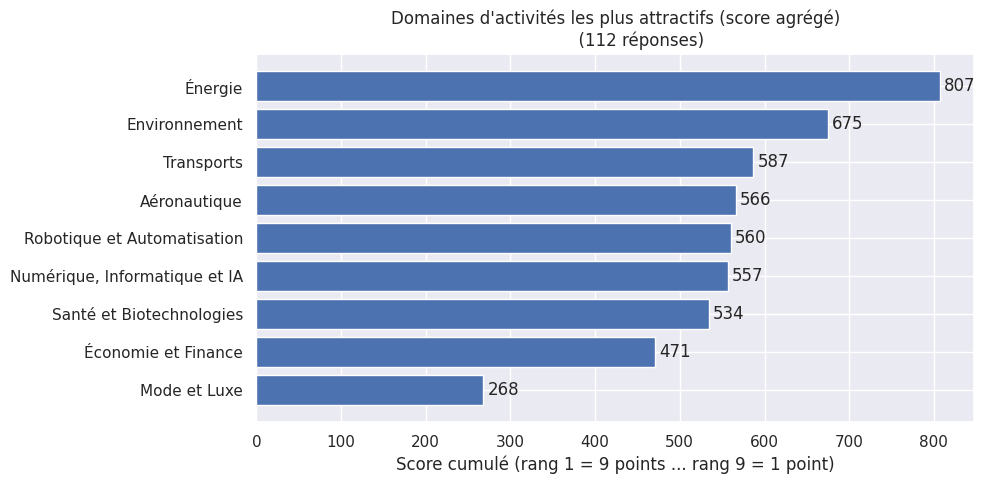

In [104]:
plot_data = domain_stats.sort_values("total_score", ascending=True)

plt.figure(figsize=(10, 5))
bars = plt.barh(plot_data.index, plot_data["total_score"])
plt.bar_label(bars, padding=3)

plt.title(f"""Domaines d'activités les plus attractifs (score agrégé)
          ({n_domain_responses} réponses)""")
plt.xlabel("Score cumulé (rang 1 = 9 points ... rang 9 = 1 point)")

plt.tight_layout()
plt.savefig("plots/domains_score.svg", bbox_inches="tight")
plt.savefig("plots/domains_score.pdf", bbox_inches="tight")
plt.show()

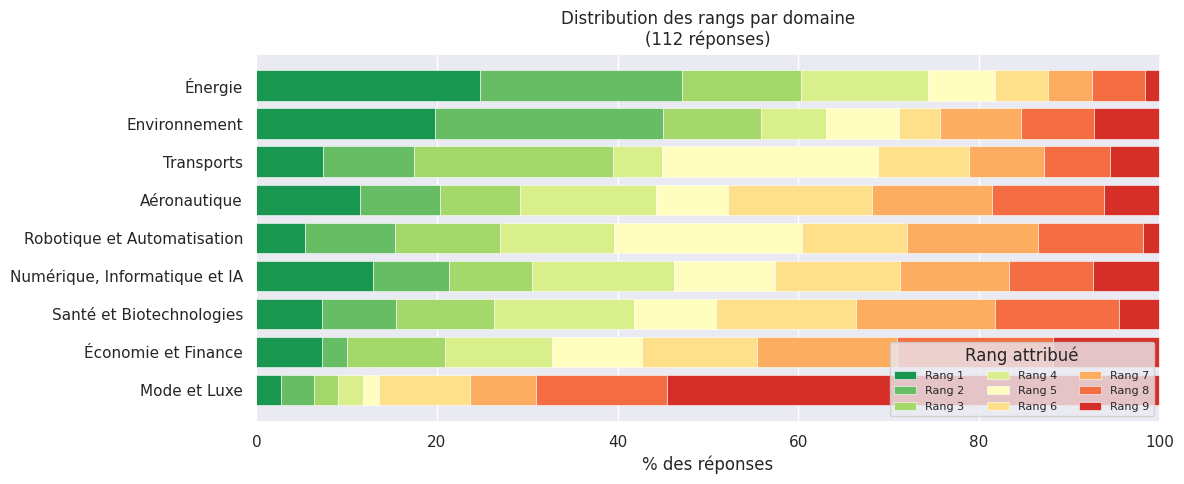

In [105]:
# Rank distribution: how often each domain was ranked 1st, 2nd, …9th
rank_matrix = {}
for record in records:
    d = record["domain"]
    r = record["rank"]
    rank_matrix.setdefault(d, {})[r] = rank_matrix.get(d, {}).get(r, 0) + 1

all_ranks = list(range(1, max_rank + 1))
domains_ordered = domain_stats.sort_values("total_score", ascending=True).index.tolist()

# Build a 2-D array: domains (rows) x ranks (cols), normalised to %
matrix = np.zeros((len(domains_ordered), len(all_ranks)))

for i, d in enumerate(domains_ordered):
    total = sum(rank_matrix.get(d, {}).values())
    for j, r in enumerate(all_ranks):
        matrix[i, j] = rank_matrix.get(d, {}).get(r, 0) / total * 100 if total else 0

# Diverging colormap, green for top ranks, red for bottom ranks
cmap = plt.get_cmap("RdYlGn_r")
rank_colors = [cmap(r / (max_rank + 1)) for r in all_ranks]

fig, ax = plt.subplots(figsize=(12, 5))
lefts = np.zeros(len(domains_ordered))
for j, r in enumerate(all_ranks):
    ax.barh(domains_ordered,
            matrix[:, j],
            left=lefts,
            color=rank_colors[j],
            label=f"Rang {r}",
            edgecolor="white",
            linewidth=0.4,)
    lefts += matrix[:, j]

ax.set_xlabel("% des réponses")
ax.set_title(f"Distribution des rangs par domaine\n"
             f"({n_domain_responses} réponses)")

ax.set_xlim(0, 100)
ax.legend(
    title="Rang attribué",
    loc="lower right",
    ncol=3,
    fontsize=8,
)

plt.tight_layout()
plt.savefig("plots/domains_rank_distribution.svg", bbox_inches="tight")
plt.savefig("plots/domains_rank_distribution.pdf", bbox_inches="tight")
plt.show()


### Autres domaines proposés

In [106]:
other_domains = df["Un domaine n'apparaissant pas dans la question précédente ?"]
other_domains = other_domains.dropna().str.strip()
other_domains

2                                             Automobile
9                                            La défense.
13                                          Construction
17                                               Conseil
19                              jeu vidéo/divertissement
25     L'action publique/sociale mais bon comme iels ...
30                                           La low tech
37                                Organisme de recherche
40                             la fonction publique !!!!
41                                            Logistique
42                                    Défense / armement
48                                              Sécurité
49                                    Recherche/physique
54                                           Aérospatial
61            Recherche ( je sais pas si c'est possible)
63                                               Conseil
71                     Génie Civil, BTP, Génie mécanique
72                             

## Y a-t-il un type de fonction qui t'intéresse particulièrement dans une entreprise ?
( par ex : R&D, recherche fondamentale, conseil, services et apps, etc... )

In [107]:
job_type = df["Y a-t-il un type de fonction qui t'intéresse particulièrement dans une entreprise ?\n( par ex : R&D, recherche fondamentale, conseil, services et apps, etc... )"]
job_type = job_type.dropna().str.strip()
job_type

1                                       Recherche ou R&D
2                                                    R&D
4                                                 r et d
13                                            Ingéniérie
16                                                   R&D
21                                                   R&D
22                                     R et D ou conseil
23     R&D !!! Et stratégie (surtout dans des grands ...
24               Service financier et analyse économique
29                R&D et Tech surtout (ML, data science)
32                                  R&D, Recherche fonda
33                      Charge d’affaires et de projets.
35     Technique (gestion de projet mais proche des t...
36                                recherche fondamentale
37                                recherche fondamentale
40               Recherche et developpement, le publique
41                                     Conseil, services
43                             

### Regroupement des fonctions par catégorie

In [ ]:
job_type_col = "Y a-t-il un type de fonction qui t'intéresse particulièrement dans une entreprise ?\n( par ex : R&D, recherche fondamentale, conseil, services et apps, etc... )"
raw_responses = df[job_type_col].dropna().str.strip()

# Mapping: catégories avec mots-clés (en minuscule pour la comparaison)
# Ordonnées par spécificité décroissante pour éviter les faux positifs
categories_mapping = {
    "R&D": ["r&d", "r et d", "rnd", "r and d"],
    "Recherche fondamentale": ["recherche fondamentale", "recherche fonda", "physique fondamentale", "astrophysique"],
    "Recherche (générale)": ["recherche"],
    "Conseil / Stratégie": ["conseil", "stratégie", "politiques publiques"],
    "Gestion de projet": ["gestion de projet", "charge d", "manager", "management"],
    "Ingénierie / Technique": ["ingéniérie", "ingénierie", "technique", "bureaux d'étude", "métiers scientifiques"],
    "Data / IA / ML": ["data science", "ml", "données", " ia"],
    "Finance / Économie": ["financier", "économique", "finance"],
    "Fonction publique": ["fonction publique"],
}

category_counts = {cat: 0 for cat in categories_mapping.keys()}
uncategorized = []

for response in raw_responses:
    response_lower = response.lower()
    found_any = False

    for category, keywords in categories_mapping.items():
        for keyword in keywords:
            if keyword in response_lower:
                category_counts[category] += 1
                found_any = True
                break

    if not found_any:
        uncategorized.append(response)

print(f"=== RÉPONSES NON CATÉGORISÉES ({len(uncategorized)}) ===")
for resp in sorted(uncategorized):
    print(f"  - {resp}")

dict_items([('R&D', ['r&d', 'r et d', 'rnd', 'r and d']), ('Recherche fondamentale', ['recherche fondamentale', 'recherche fonda', 'physique fondamentale', 'astrophysique']), ('Recherche (générale)', ['recherche']), ('Conseil / Stratégie', ['conseil', 'stratégie', 'politiques publiques']), ('Gestion de projet', ['gestion de projet', 'charge d', 'manager', 'management']), ('Ingénierie / Technique', ['ingéniérie', 'ingénierie', 'technique', "bureaux d'étude", 'métiers scientifiques']), ('Data / IA / ML', ['data science', 'ml', 'données', ' ia']), ('Finance / Économie', ['financier', 'économique', 'finance']), ('Fonction publique', ['fonction publique'])])

=== RÉPONSES NON CATÉGORISÉES (2) ===
  - Métiers pluridisciplinaires à l’interface de plusieurs métiers
  - tous les métiers dans l’aéronautique


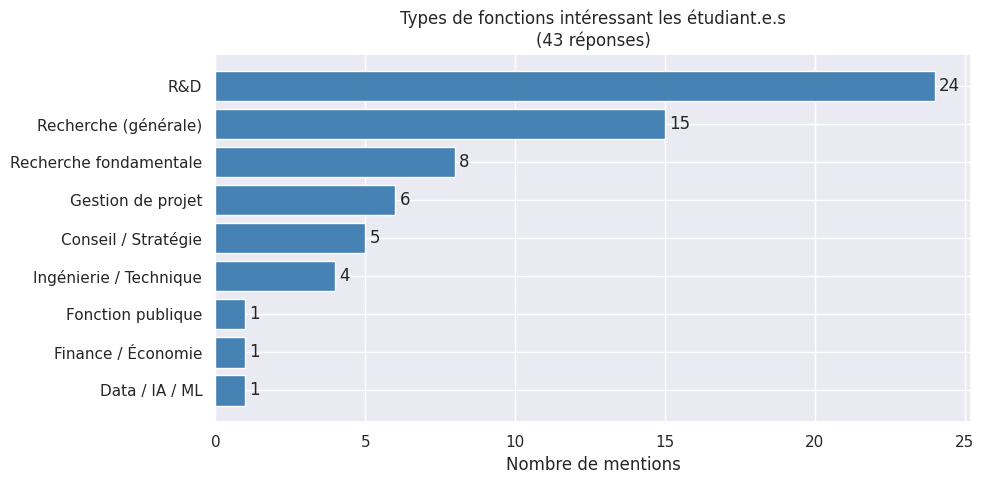

In [ ]:
plot_data = sorted(category_counts.items(), key=lambda x: x[1])
labels = [x[0] for x in plot_data]
values = [x[1] for x in plot_data]

plt.figure(figsize=(10, 5))
bars = plt.barh(labels, values, color='steelblue')
plt.bar_label(bars, padding=3)

plt.title(f"Types de fonctions intéressant les étudiant.e.s\n({len(raw_responses)} réponses)")
plt.xlabel("Nombre de mentions")

plt.tight_layout()
plt.savefig("plots/job_functions.svg", bbox_inches="tight")
plt.savefig("plots/job_functions.pdf", bbox_inches="tight")
plt.show()

## Qu'espères-tu obtenir d'un évènement entreprise ?

In [110]:
hopes = df["Qu'espères-tu obtenir d'un évènement entreprise"]
hopes = hopes.dropna().str.strip()
hopes

1      Rencontrer des travailleurs, découvrir des ent...
5      Informations générales sur l’entreprise, contacts
7                                              une pizza
11     Mieux connaître l’entreprise et la vie des emp...
12     Des contacts et une meilleure connaissance du ...
13                             Idée de carrière, contact
16                          Des contacts et des conseils
18                                              un stage
20                                        Un stage pitié
22     savoir plus précisément quelles sont les tâche...
23     Comprendre le métier des personnes invitées, c...
24     une bonne compréhension des enjeux financiers ...
25     Des pizzas et un panorama un peu précis de l'e...
27     Connaître un peu mieux les tâches au sein de l...
29                                              Un stage
31                                         Un témoignage
32         une pizza et un stage et de la sauce piquante
33     De la connaissance sur c